In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    f1_score, roc_auc_score,
    precision_score, recall_score
)
import joblib

In [2]:
# 1. Load model, features, baseline & prod data

clf      = joblib.load("baseline_model.pkl")
FEATURES = joblib.load("feature_list.pkl")
threshold = joblib.load("optimal_threshold.pkl")

baseline = pd.read_csv("baseline_metrics.csv").iloc[0].to_dict()

prod_files = ["../drift_1.csv", "../drift_2.csv", "../drift_3.csv", "../drift_4.csv", "../drift_5.csv"]
prod_dfs   = [pd.read_csv(f) for f in prod_files]

In [3]:
# 2. Evaluate model on each production dataset

prod_metrics = []

for i, df in enumerate(prod_dfs):
    X = df[FEATURES]
    y = df["Class"]

    y_proba = clf.predict_proba(X)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)

    prod_metrics.append({
        "dataset":   f"Prod {i+1}",
        "F1":        f1_score(y, y_pred, zero_division=0),
        "AUC-ROC":   roc_auc_score(y, y_proba),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall":    recall_score(y, y_pred, zero_division=0),
    })

prod_df = pd.DataFrame(prod_metrics)

In [4]:
# 3. Print metrics table with degradation

print("── Performance: Baseline vs Production ─────────────────")
print(f"\n{'Dataset':<10} {'F1':>8} {'AUC-ROC':>10} {'Precision':>12} {'Recall':>10}")
print("-" * 50)

# Baseline row
print(f"{'Baseline':<10} {baseline['F1']:>8.4f} {baseline['AUC-ROC']:>10.4f} "
      f"{baseline['Precision']:>12.4f} {baseline['Recall']:>10.4f}")

# Production rows + delta
for _, row in prod_df.iterrows():
    f1_delta  = row["F1"]        - baseline["F1"]
    auc_delta = row["AUC-ROC"]   - baseline["AUC-ROC"]
    pre_delta = row["Precision"] - baseline["Precision"]
    rec_delta = row["Recall"]    - baseline["Recall"]
    print(f"{row['dataset']:<10} {row['F1']:>8.4f} {row['AUC-ROC']:>10.4f} "
          f"{row['Precision']:>12.4f} {row['Recall']:>10.4f}  "
          f"ΔF1={f1_delta:+.4f}")

── Performance: Baseline vs Production ─────────────────

Dataset          F1    AUC-ROC    Precision     Recall
--------------------------------------------------
Baseline     0.8830     0.9529       0.9222     0.8469
Prod 1       0.0000     0.5133       0.0000     0.0000  ΔF1=-0.8830
Prod 2       0.0000     0.4646       0.0000     0.0000  ΔF1=-0.8830
Prod 3       0.6475     0.9998       1.0000     0.4787  ΔF1=-0.2355
Prod 4       0.0000     0.5172       0.0000     0.0000  ΔF1=-0.8830
Prod 5       0.4252     0.9319       1.0000     0.2700  ΔF1=-0.4578


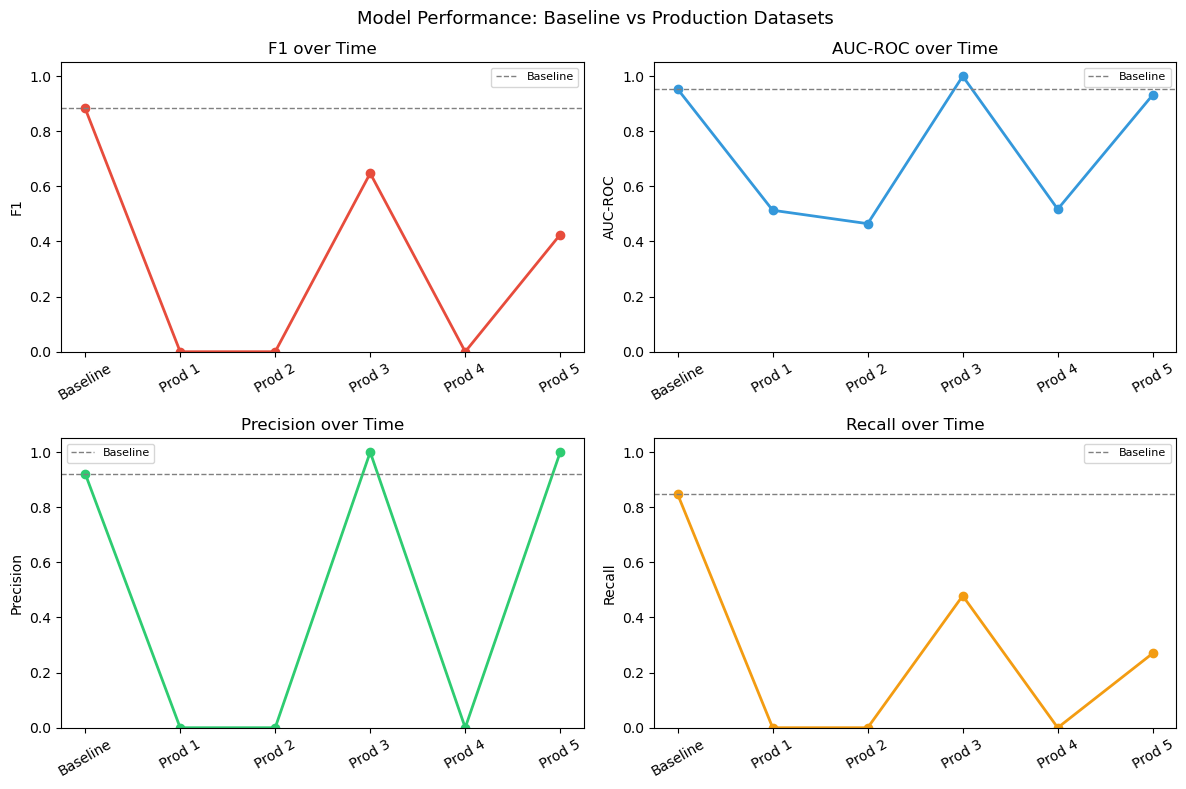

In [5]:
metrics     = ["F1", "AUC-ROC", "Precision", "Recall"]
colors      = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
x_labels    = ["Baseline"] + [f"Prod {i+1}" for i in range(5)]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[idx]
    values = [baseline[metric]] + prod_df[metric].tolist()
    ax.plot(x_labels, values, marker="o", color=color, linewidth=2)
    ax.axhline(y=baseline[metric], color="grey", linestyle="--",
               linewidth=1, label="Baseline")
    ax.set_title(f"{metric} over Time")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)

plt.suptitle("Model Performance: Baseline vs Production Datasets", fontsize=13)
plt.tight_layout()
plt.show()

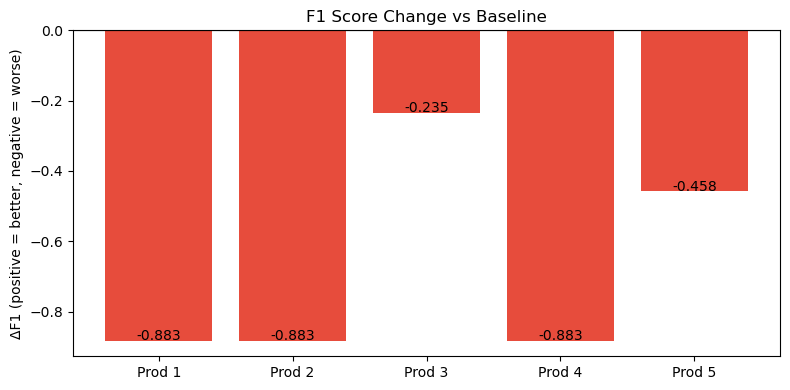

In [6]:
prod_df["F1_delta"] = prod_df["F1"] - baseline["F1"]

colors_bar = ["#2ecc71" if d >= 0 else "#e74c3c" for d in prod_df["F1_delta"]]

plt.figure(figsize=(8, 4))
bars = plt.bar(prod_df["dataset"], prod_df["F1_delta"], color=colors_bar)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("F1 Score Change vs Baseline")
plt.ylabel("ΔF1 (positive = better, negative = worse)")
for bar, val in zip(bars, prod_df["F1_delta"]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f"{val:+.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()


── Drift vs Performance Link ─────────────────────────
dataset       F1  F1_delta  mean_psi
 Prod 1 0.000000 -0.882979  0.249807
 Prod 2 0.000000 -0.882979  0.334466
 Prod 3 0.647482 -0.235497  0.235862
 Prod 4 0.000000 -0.882979  0.240359
 Prod 5 0.425197 -0.457782  0.236193


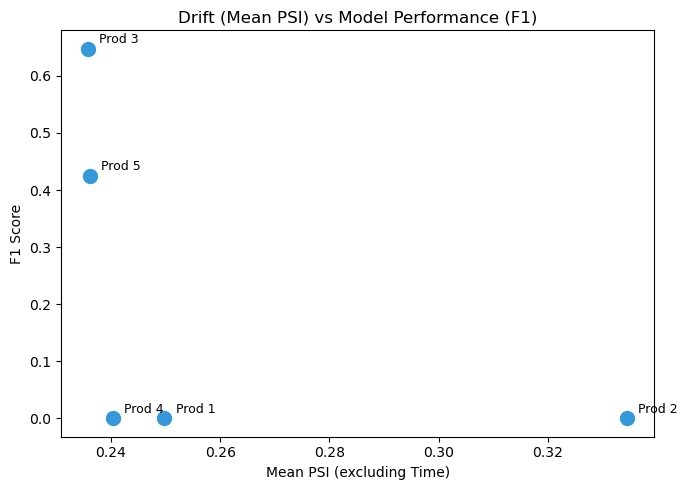

In [7]:
# 6. Link drift to degradation

psi_results = pd.read_csv("psi_results.csv")

# Get mean PSI per dataset (excluding Time — structural artifact)
mean_psi = (psi_results[psi_results["feature"] != "Time"]
            .groupby("dataset")["psi"]
            .mean()
            .reset_index()
            .rename(columns={"psi": "mean_psi"}))

# Merge with F1
link_df = prod_df[["dataset", "F1", "F1_delta"]].merge(mean_psi, on="dataset")

print("\n── Drift vs Performance Link ─────────────────────────")
print(link_df.to_string(index=False))

# Scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(link_df["mean_psi"], link_df["F1"], color="#3498db", s=100, zorder=3)
for _, row in link_df.iterrows():
    plt.annotate(row["dataset"],
                 (row["mean_psi"], row["F1"]),
                 textcoords="offset points", xytext=(8, 4), fontsize=9)
plt.xlabel("Mean PSI (excluding Time)")
plt.ylabel("F1 Score")
plt.title("Drift (Mean PSI) vs Model Performance (F1)")
plt.tight_layout()
plt.show()

In [8]:
prod_df.to_csv("production_metrics.csv", index=False)
print("\nProduction metrics saved.")


Production metrics saved.
